In [1]:
import numpy as np
import time
from tqdm import tqdm
import matplotlib.pyplot as plt  # For visualizing input/reconstruction
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.optim as optim

# S3-VAE with batch normalization:

In [11]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(2, 32, kernel_size=3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Dynamically compute final feature map size
        dummy_input = torch.zeros(1, 2, img_size, img_size)  # Fake input to infer shape
        with torch.no_grad():
            dummy_output = self.conv4(self.conv3(self.conv2(self.conv1(dummy_input))))
        self.final_size = dummy_output.shape[-1]  # Get actual final size (should be 8)

        self.fc_mu = nn.Linear(256 * self.final_size * self.final_size, latent_dim)
        self.fc_logvar = nn.Linear(256 * self.final_size * self.final_size, latent_dim)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = torch.flatten(x, start_dim=1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(Decoder, self).__init__()

        # Ensure consistency with encoder
        self.final_size = 8  # Since we dynamically compute it in Encoder, we ensure it's consistent
        self.fc = nn.Linear(latent_dim, 256 * self.final_size * self.final_size)  

        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn1 = nn.BatchNorm2d(128)

        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn3 = nn.BatchNorm2d(32)

        self.deconv4 = nn.ConvTranspose2d(32, 2, kernel_size=3, stride=2, padding=1, output_padding=1)
        
        # Final Upsampling to ensure exact output size
        self.final_upsample = nn.Upsample(size=(140, 140), mode='bilinear', align_corners=True)


    def forward(self, z):
        final_size = 8
        x = self.fc(z)
        x = x.view(-1, 256, final_size, final_size)
        x = F.relu(self.bn1(self.deconv1(x)))
        x = F.relu(self.bn2(self.deconv2(x)))
        x = F.relu(self.bn3(self.deconv3(x)))
        x = torch.sigmoid(self.deconv4(x))  # Output is 140x140 now
        x = self.final_upsample(x)  # Ensure output size is exactly 140x140
        return x


class VAE(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim, img_size)
        self.decoder = Decoder(latent_dim, img_size)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar

# S3-VAE with maxPooling:

In [ ]:

class Encoder(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(2, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.MaxPool2d(2)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.MaxPool2d(2)
        
        final_size = img_size // 16
        self.fc_mu = nn.Linear(256 * final_size * final_size, latent_dim)
        self.fc_logvar = nn.Linear(256 * final_size * final_size, latent_dim)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = torch.flatten(x, start_dim=1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar
    
    
class Decoder(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(Decoder, self).__init__()
        
        final_size = img_size // 16
        self.fc = nn.Linear(latent_dim, 256 * final_size * final_size)
        
        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=1, padding=1)
        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=1, padding=1)
        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=1, padding=1)
        self.deconv4 = nn.Conv2d(32, 2, kernel_size=3, stride=1, padding=1)
        self.final_upsample = nn.Upsample(size=(140, 140), mode='bilinear', align_corners=True)  # Ensures exact size

        
    def forward(self, z):
        final_size = 8
        x = self.fc(z)
        x = x.view(-1, 256, final_size, final_size)
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        x = F.relu(self.deconv3(x))
        x = F.relu(self.deconv4(x))
        x = torch.sigmoid(self.final_upsample(x))
        return x
    
    
class VAE(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim, img_size)
        self.decoder = Decoder(latent_dim, img_size)
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar
    

In [3]:
class MarkerDataset(Dataset):
    def __init__(self, marker_name, img_size=140, data_dir='B_cells_Data'):
        self.images = np.load(f"{data_dir}/{marker_name}_images.npy")  # Shape: (N, 2, H, W)
        self.labels = np.load(f"{data_dir}/{marker_name}_labels.npy")  # Shape: (N,)
        self.patient_labels = np.load(f"{data_dir}/{marker_name}_patient_labels.npy")  # Shape: (N,)
        
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size)),  # Resizing
            transforms.Normalize(mean=[0.5, 0.5], std=[0.5, 0.5])  # Normalize both channels
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  # Shape: (2, H, W)
        label = self.labels[idx]
        patient_id = self.patient_labels[idx]
        
        img = torch.tensor(img, dtype=torch.float32)  # Convert to Tensor
        return img, label, patient_id

# Example: Load BTK dataset
btk_dataset = MarkerDataset("BTK")
btk_loader = DataLoader(btk_dataset, batch_size=32, shuffle=True)
print(f"Total batches: {len(btk_loader)}")

Total batches: 56


In [4]:
def visualize_reconstructions(vae, dataloader, device):
    vae.eval()
    with torch.no_grad():
        for batch in dataloader:
            images = batch[0].to(device)
            recon_images, _, _ = vae(images)
            # Visualize first 5 images and their reconstructions
            fig, axes = plt.subplots(2, 5, figsize=(15, 6))
            for i in range(5):
                # Original
                axes[0, i].imshow(images[i, 0].cpu().numpy(), cmap="gray")
                axes[0, i].set_title("Original")
                axes[0, i].axis("off")
                # Reconstructed
                axes[1, i].imshow(recon_images[i, 0].cpu().numpy(), cmap="gray")
                axes[1, i].set_title("Reconstructed")
                axes[1, i].axis("off")
            plt.show()
            break

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE(latent_dim=20, img_size=140).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

#Additonal step:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [11]:
# Debugging: Check if the forward pass works
try:
    images, _, _ = next(iter(btk_loader))  # Get one batch of images
    images = images.to(device)
    #print(images)

    with torch.no_grad():
        #print("I'm in the try block")
        recon_images, mu, logvar = vae(images)
    #print("I'm outside the try block")

    print("Forward pass successful! Model is working correctly.")
    print(f"Reconstructed Image Shape: {recon_images.shape}")
    print(f"Mean Shape: {mu.shape}, Logvar Shape: {logvar.shape}")
except Exception as e:
    print(f"Error during forward pass: {e}")


Forward pass successful! Model is working correctly.
Reconstructed Image Shape: torch.Size([32, 2, 140, 140])
Mean Shape: torch.Size([32, 20]), Logvar Shape: torch.Size([32, 20])


In [6]:
def loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss (MSE for pixel-level similarity)
    reconstruction_loss = F.mse_loss(recon_x, x, reduction='sum')
    # KL divergence (latent space regularization)
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return reconstruction_loss + kl_divergence

In [8]:
# Training Loop
num_epochs = 10
vae.train()
for epoch in range(num_epochs):
    total_loss = 0
    with tqdm(btk_loader, unit="batch") as tepoch:
        for batch in tepoch:
            tepoch.set_description(f"Epoch {epoch+1}")
            images, _, _ = batch
            images = images.to(device)
            optimizer.zero_grad()
            recon_images, mu, logvar = vae(images)
            loss = loss_function(recon_images, images, mu, logvar)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            tepoch.set_postfix(loss=loss.item() / len(images))
    scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {total_loss / len(btk_loader.dataset):.4f}")

print("Training complete!")

Epoch 1:   0%|          | 0/56 [00:13<?, ?batch/s]


KeyboardInterrupt: 

In [14]:
num_epochs = 10
vae.train()
for epoch in range(num_epochs):
    total_loss = 0
    with tqdm(btk_loader, unit="batch") as tepoch:
        for batch_idx, batch in enumerate(tepoch):
            tepoch.set_description(f"Epoch {epoch+1}")
            step_start_time = time.time()  # Start step timer

            images, _, _ = batch
            images = images.to(device)

            t0 = time.time()
            optimizer.zero_grad()  # Zero gradients
            t1 = time.time()
            zero_grad_time = t1 - t0
            #print(f"zero_grad_time: {zero_grad_time:.4f}s")
            
            recon_images, mu, logvar = vae(images)  # Forward pass
            t2 = time.time()
            forward_time = t2 - t1
            #print(f"forward_time: {forward_time:.4f}s")
            
            loss = loss_function(recon_images, images, mu, logvar)  # Compute loss
            t3 = time.time()
            loss_time = t3 - t2
            #print(f"loss_time: {loss_time:.4f}s")
            
            loss.backward()  # Backward pass
            t4 = time.time()
            backward_time = t4 - t3
            #print(f"backward_time: {backward_time:.4f}s")
            
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)  # Gradient clipping
            t5 = time.time()
            clip_time = t5 - t4
            #print(f"clip_time: {clip_time:.4f}s")
            
            optimizer.step()  # Optimizer step
            t6 = time.time()
            optimizer_time = t6 - t5
            #print(f"optimizer_time: {optimizer_time:.4f}s")

            step_time = t6 - step_start_time

            # Print timing for each operation
            print(f"Step {batch_idx + 1} times: zero_grad={zero_grad_time:.4f}s, forward={forward_time:.4f}s, loss_calc={loss_time:.4f}s, backward={backward_time:.4f}s, clip={clip_time:.4f}s, optimize={optimizer_time:.4f}s, total={step_time:.4f}s")

            total_loss += loss.item()
            tepoch.set_postfix(loss=loss.item() / len(images))

    scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {total_loss / len(btk_loader.dataset):.4f}")


  0%|          | 0/56 [00:00<?, ?batch/s]

Epoch 1:   2%|▏         | 1/56 [00:02<01:54,  2.08s/batch, loss=7.57e+7]

Step 1 times: zero_grad=0.0004s, forward=0.7162s, loss_calc=0.0043s, backward=1.3034s, clip=0.0070s, optimize=0.0203s, total=2.0516s


Epoch 1:   4%|▎         | 2/56 [00:03<01:41,  1.87s/batch, loss=8.99e+7]

Step 2 times: zero_grad=0.0047s, forward=0.6040s, loss_calc=0.0073s, backward=1.0044s, clip=0.0115s, optimize=0.0365s, total=1.6687s


...

Step 54 times: zero_grad=0.0048s, forward=0.5797s, loss_calc=0.0062s, backward=0.4828s, clip=0.0020s, optimize=0.0207s, total=1.0966s


Epoch 10:  98%|█████████▊| 55/56 [01:16<00:01,  1.01s/batch, loss=7.47e+7]

Step 55 times: zero_grad=0.0040s, forward=0.3248s, loss_calc=0.0030s, backward=0.5465s, clip=0.0023s, optimize=0.0200s, total=0.9010s


Epoch 10: 100%|██████████| 56/56 [01:17<00:00,  1.39s/batch, loss=4.75e+7]

Step 56 times: zero_grad=0.0032s, forward=0.2799s, loss_calc=0.0054s, backward=0.3983s, clip=0.0024s, optimize=0.0199s, total=0.7092s
Epoch 10: Loss = 79814935.3639


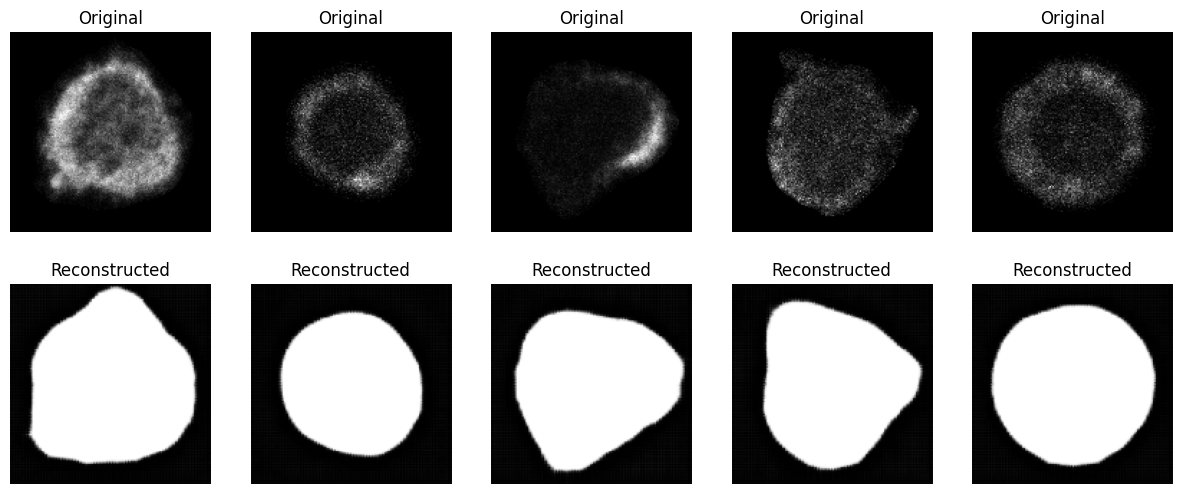

In [15]:
visualize_reconstructions(vae, btk_loader, device)